# Práctica 8: Predicciones

Para esta octava práctica, se ejecuta código para realizar una predicción por medio de los datos, haciendo uso de series de tiempo y regresión lineal.

## Librerías

Se importan las librerías necesarias.

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

## Importación de los datos desde CSV

Se crea una copia del dataset limpio para manejarlo.

In [54]:
# Se carga el conjunto de datos limpio.
df_original = pd.read_csv("C:\\Users\\Paty-\\OneDrive\\Documentos\\04 Facultad\\Séptimo Semestre\\Minería de Datos\\CardiovascularDiseaseDataMining\\Practica1\\cardiovascular_disease_cleaned.csv", sep=";")

# Se crea una copia del conjunto de datos limpio para trabajar en ella.
df = df_original.copy()

# Se muestran las primeras filas del conjunto de datos.
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,birth_date,age_scaled,height_scaled,weight_scaled,ap_hi_scaled,ap_lo_scaled
0,0,50,Male,168,62.0,110,80,Normal,Normal,No,No,Yes,No,1968-10-15 09:32:17.835072,-0.426244,0.477190,-0.911143,-1.149090,-0.221435
1,1,55,Female,156,85.0,140,90,Well Above Normal,Normal,No,No,Yes,Yes,1963-10-07 09:32:17.835072,0.315922,-1.116157,0.963057,0.950300,1.081779
2,2,51,Female,165,64.0,130,70,Well Above Normal,Normal,No,No,No,Yes,1967-07-09 09:32:17.835072,-0.277811,0.078853,-0.748169,0.250504,-1.524649
3,3,48,Male,169,82.0,150,100,Normal,Normal,No,No,Yes,Yes,1970-11-24 09:32:17.835072,-0.723111,0.609969,0.718596,1.650097,2.384993
4,8,59,Female,151,67.0,120,80,Above Normal,Above Normal,No,No,No,No,1959-02-24 09:32:17.835072,0.909656,-1.780052,-0.503708,-0.449293,-0.221435


## Limpieza para la variable de fecha y cardio

Para la variable de cardio, se hace el mapeado, para poder obtener un promedio a utilizar en la predicción.

In [55]:
df['cardio'] = df['cardio'].map({'Yes': 1, 'No': 0})

Se realiza una verificación en la variable para evitar errores de formatos.

In [56]:
df['birth_date'] = pd.to_datetime(
    df['birth_date'],
    errors='coerce'
)

In [57]:
df = df.dropna(subset=['birth_date'])

## Creación de la variable de tiempo

In [58]:
df['year'] = df['birth_date'].dt.year

## Serie de tiempo

Se agrupan y ordenan los valores.

In [59]:
df_time = df.groupby('year').mean(numeric_only=True).reset_index()

df_time = df_time.sort_values('year')

## Variables para el modelo

In [60]:
X = df_time[['year']]

y = df_time['cardio']

## Modelo de regresión lineal

In [61]:
model = LinearRegression()
model.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## Predicciones y score en datos existentes

In [62]:
y_pred = model.predict(X)

r2 = r2_score(y, y_pred)
print("R2 score:", r2)

R2 score: 0.894030919630386


## Predicciones futuras

Se realiza una predicción de 10 años con uso del modelo de regresión.

In [63]:
future_years = pd.DataFrame({
    'year': np.arange(
        df_time['year'].max(),
        df_time['year'].max() + 10
    )
})

future_predictions = model.predict(future_years)

## Visualización

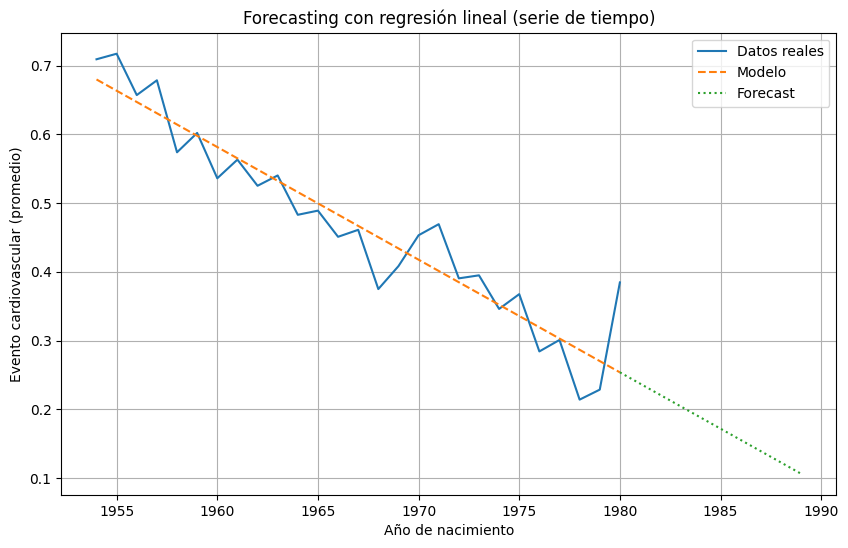

In [64]:
plt.figure(figsize=(10,6))

# Datos reales del dataset.
plt.plot(df_time['year'], y, label="Datos reales")

# Prediccion del modelo sobre los datos históricos.
plt.plot(df_time['year'], y_pred, linestyle='--', label="Modelo")

# Predicciones futuras del modelo.
plt.plot(future_years, future_predictions, linestyle=':', label="Forecast")

plt.xlabel("Año de nacimiento")
plt.ylabel("Evento cardiovascular (promedio)")
plt.title("Forecasting con regresión lineal (serie de tiempo)")

plt.legend()
plt.grid()

plt.show()

## Resultados

Porcentaje obtenido de la predicción para personas según su fecha de nacimiento.

In [65]:
df_future = pd.DataFrame({
    'year': future_years['year'],
    'predicted_cardio': future_predictions
})

print("\nPredicciones futuras:")
print(df_future)


Predicciones futuras:
   year  predicted_cardio
0  1980          0.253826
1  1981          0.237442
2  1982          0.221058
3  1983          0.204674
4  1984          0.188290
5  1985          0.171906
6  1986          0.155522
7  1987          0.139138
8  1988          0.122754
9  1989          0.106370
